In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse as sp
import time
import anndata as an
import scanpy as sc
import scanpy.external as sce
import h5py

# Read in processed AnnData

In [2]:
%%time
# load in processed adata
path = "/nfs/turbo/umms-indikar/shared/projects/hybrid_reprogramming/anndata/processed_all_groups_v2.h5ad"
adata = sc.read_h5ad(path)
sc.logging.print_memory_usage()
adata

Memory usage: current 2.41 GB, difference +2.41 GB
CPU times: user 547 ms, sys: 1.77 s, total: 2.32 s
Wall time: 7.32 s


/nfs/turbo/umms-indikar/Jillian/conda-envs/rapids/lib/python3.13/site-packages/anndata/logging.py:57: FutureWarning: The specified parameters ('newline',) are no longer positional. Please specify them like `newline=False`
  print(format_memory_usage(get_memory_usage(), msg, newline))


AnnData object with n_obs × n_vars = 16296 × 25126
    obs: 'MYOD-fb_counts', 'PRRX1-fb_counts', 'PRRX1_MYOD-fb_counts', 'assigned_condition', 'total_fb_counts', 'condition_counts_rate', 'G1-fb_counts', 'G2M-fb_counts', 'S-fb_counts', 'dataset', 'total_reads', 'total_genes', 'pooled_condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier', 'mt_outlier', 'n_genes', 'doublet_score', 'predicted_doublet', 'S_score', 'G2M_score', 'phase', 'leiden', 'cluster_str', 'leiden_split'
    var: 'gene_id', 'gene_type', 'Chromosome', 'Start', 'End', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'mean', 'st

# Read in spliced MYOD counts

In [3]:
%%time
# read in exo vs endo myod counts
fpath = "/nfs/turbo/umms-indikar/shared/projects/hybrid_reprogramming/data/exo_vs_endo/runs/minimap_spliced/merged_mmyod_spliced.h5ad"
bdata = sc.read_h5ad(fpath)

# filter for cells present in adata
bdata.obs_names = [f"{cb}_hybrid" for cb in bdata.obs_names] # make sure cell IDs match
bdata = bdata[bdata.obs.index.isin(adata.obs_names), :].copy()

print(bdata)

bdata.obs.head()

AnnData object with n_obs × n_vars = 9394 × 28702
    obs: 'MYOD-fb_counts', 'PRRX1-fb_counts', 'PRRX1_MYOD-fb_counts', 'assigned_condition', 'total_fb_counts', 'condition_counts_rate', 'G1-fb_counts', 'G2M-fb_counts', 'S-fb_counts', 'dataset', 'total_reads', 'total_genes', 'obs_condition_id', 'condition', 'chr11_primary', 'chr11_secondary', 'chr11_supplementary', 'chrMMYOD_primary', 'chrMMYOD_secondary', 'chrMMYOD_supplementary', 'ratio_primary', 'myod_total', 'mmyod_total', 'ratio_all', 'dpt_pseudotime', 'hour_timepoint'
    var: 'gene_id', 'gene_type', 'Chromosome', 'Start', 'End'
    uns: 'assigned_condition_colors', 'diffmap_evals', 'iroot', 'neighbors', 'pca', 'tsne', 'umap'
    obsm: 'X_diffmap', 'X_pca', 'X_tsne', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'
CPU times: user 335 ms, sys: 595 ms, total: 931 ms
Wall time: 1.81 s


,MYOD-fb_counts,PRRX1-fb_counts,PRRX1_MYOD-fb_counts,assigned_condition,total_fb_counts,condition_counts_rate,G1-fb_counts,G2M-fb_counts,S-fb_counts,dataset,...,chr11_supplementary,chrMMYOD_primary,chrMMYOD_secondary,chrMMYOD_supplementary,ratio_primary,myod_total,mmyod_total,ratio_all,dpt_pseudotime,hour_timepoint
AAACCAAAGCAACTGC_hybrid,0.0,0.0,25.0,PRRX1_MYOD,25.0,1.000000,0.0,0.0,0.0,Hybrid,...,0.0,63.0,29.0,1.0,0.315217,50.0,93.0,0.349650,0.022087,11
AAACCAAAGTAGGGCA_hybrid,14.0,1.0,1.0,MYOD,16.0,0.875000,0.0,0.0,0.0,Hybrid,...,0.0,32.0,11.0,0.0,0.255814,22.0,43.0,0.338462,0.045417,47
AAACCAAAGTCTAGGC_hybrid,0.0,0.0,25.0,PRRX1_MYOD,25.0,1.000000,0.0,0.0,0.0,Hybrid,...,0.0,20.0,15.0,0.0,0.428571,24.0,35.0,0.406780,0.018075,7
AAACCATTCACGTAAT_hybrid,2.0,19.0,2.0,PRRX1,23.0,0.826087,0.0,0.0,0.0,Hybrid,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.044319,46
AAACCATTCAGGCAGA_hybrid,0.0,22.0,0.0,PRRX1,22.0,1.000000,0.0,0.0,0.0,Hybrid,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.021298,10


In [5]:
bdata.obs[['chr11_primary', 'myod_total', 'chrMMYOD_primary', 'mmyod_total']].describe()

,chr11_primary,myod_total,chrMMYOD_primary,mmyod_total
count,9394.000000,9394.000000,9394.000000,9394.000000
mean,6.739940,11.040558,12.730360,19.550138
std,8.769531,14.111084,16.043438,24.408870
min,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000
50%,3.000000,6.000000,7.000000,11.000000
75%,11.000000,17.000000,20.000000,31.000000
max,73.000000,113.000000,124.000000,191.000000


In [6]:
# create cell ID -- exo vs endo mapping
# myod_df = bdata.obs[['myod_total', 'mmyod_total']].copy()
# myod_df = myod_df.rename(columns={'myod_total': 'MYOD1_endo', 'mmyod_total': 'MYOD1_exo'})

# only take primary alignments
myod_df = bdata.obs[['chr11_primary', 'chrMMYOD_primary']].copy()
myod_df = myod_df.rename(columns={'chr11_primary': 'MYOD1_endo', 'chrMMYOD_primary': 'MYOD1_exo'})

print(myod_df.shape)
myod_df.head()

(9394, 2)


,MYOD1_endo,MYOD1_exo
AAACCAAAGCAACTGC_hybrid,29.0,63.0
AAACCAAAGTAGGGCA_hybrid,11.0,32.0
AAACCAAAGTCTAGGC_hybrid,15.0,20.0
AAACCATTCACGTAAT_hybrid,0.0,0.0
AAACCATTCAGGCAGA_hybrid,0.0,0.0


# Merge into adata

In [7]:
### Make counts matrix for MYOD1_endo/exo, mapped to adata cell order

n_cells = adata.shape[0]
all_cells = adata.obs_names.tolist()

# Create zero arrays for the two new genes
myod1_endo_counts = np.zeros(n_cells, dtype=int)
myod1_exo_counts  = np.zeros(n_cells, dtype=int)

# Map adata cell names to index
cell_to_idx = {cell: idx for idx, cell in enumerate(all_cells)}

# Fill counts for hybrid cells 
for cell in myod_df.index:
    if cell in cell_to_idx:
        idx = cell_to_idx[cell]
        myod1_endo_counts[idx] = myod_df.loc[cell, 'MYOD1_endo']
        myod1_exo_counts[idx]  = myod_df.loc[cell, 'MYOD1_exo']
        
myod_counts_matrix = np.stack([myod1_endo_counts, myod1_exo_counts], axis=1)  # (n_cells, 2)


### Get original counts matrix (X)
layer = 'raw_counts'
if sp.issparse(adata.layers[layer]):
    raw_counts_dense = adata.layers[layer].toarray()
else:
    raw_counts_dense = np.array(adata.layers[layer])

print(f"adata.X (raw counts) shape: {raw_counts_dense.shape}")
print(f"MYOD counts matrix shape: {myod_counts_matrix.shape}")

## concatenate counts matrices
raw_counts_new = np.concatenate([raw_counts_dense, myod_counts_matrix], axis=1)
print('New shape:', raw_counts_new.shape)

new_var_names = list(adata.var_names) + ['MYOD1_endo', 'MYOD1_exo']

adata.X (raw counts) shape: (16296, 25126)
MYOD counts matrix shape: (16296, 2)
New shape: (16296, 25128)


In [8]:
def expand_var_df(orig_var, new_genes):
    """
    Add new genes to the var DataFrame, copying column dtypes and filling with sensible defaults.
    """
    # Build new rows with same columns as orig_var, matching dtypes
    new_rows = []
    for gene in new_genes:
        values = []
        for col in orig_var.columns:
            # dtype and default filler
            dt = orig_var[col].dtype
            if pd.api.types.is_bool_dtype(dt):
                # Look for existing value to copy, else False
                values.append(False)
            elif isinstance(dt, pd.CategoricalDtype):
                values.append(orig_var[col].cat.categories[0] if len(orig_var[col].cat.categories) else "unknown")
            elif pd.api.types.is_numeric_dtype(dt):
                values.append(np.nan)
            elif pd.api.types.is_string_dtype(dt):
                values.append("unknown")
            else:
                # fallback for other/tag columns
                values.append(np.nan)
        new_rows.append(values)
    new_var = pd.DataFrame(new_rows, index=new_genes, columns=orig_var.columns)
    
    # Concatenate
    expanded = pd.concat([orig_var.copy(), new_var])
    # Restore categorical columns
    for col in orig_var.columns:
        dt = orig_var[col].dtype
        if isinstance(dt, pd.CategoricalDtype):
            expanded[col] = expanded[col].astype(orig_var[col].dtype)
        elif pd.api.types.is_bool_dtype(dt):
            expanded[col] = expanded[col].astype(bool)
        # No need to force dtype for non-problematic columns
    return expanded



new_var_df = expand_var_df(adata.var, ['MYOD1_endo', 'MYOD1_exo'])

# Copy info from canonical MYOD1 entry
original_gene = 'MYOD1'
for new_gene in ['MYOD1_endo', 'MYOD1_exo']:
    if original_gene in adata.var.index:
        for col in adata.var.columns:
            new_var_df.loc[new_gene, col] = adata.var.loc[original_gene, col]

/tmp/ipykernel_934704/3615741810.py:28: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  expanded = pd.concat([orig_var.copy(), new_var])


In [9]:
adata

AnnData object with n_obs × n_vars = 16296 × 25126
    obs: 'MYOD-fb_counts', 'PRRX1-fb_counts', 'PRRX1_MYOD-fb_counts', 'assigned_condition', 'total_fb_counts', 'condition_counts_rate', 'G1-fb_counts', 'G2M-fb_counts', 'S-fb_counts', 'dataset', 'total_reads', 'total_genes', 'pooled_condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier', 'mt_outlier', 'n_genes', 'doublet_score', 'predicted_doublet', 'S_score', 'G2M_score', 'phase', 'leiden', 'cluster_str', 'leiden_split'
    var: 'gene_id', 'gene_type', 'Chromosome', 'Start', 'End', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'mean', 'st

In [10]:
# ------------------- Create expanded AnnData ------------------------
adata_expanded = an.AnnData(
    X=np.zeros((adata.n_obs, len(new_var_df)), dtype=float),
    obs=adata.obs.copy(),
    var=new_var_df,
)
for key in adata.layers.keys():
    arr = adata.layers[key]
    arr = arr.toarray() if hasattr(arr, "toarray") else np.array(arr)
    arr_expanded = np.concatenate([arr, np.zeros((adata.n_obs, 2), dtype=arr.dtype)], axis=1)
    adata_expanded.layers[key] = arr_expanded

adata_expanded.layers['raw_counts_new'] = raw_counts_new

# copy over relevent info

# obsm_cols = ['X_umap', 'X_pca_harmony', 'X_pca_original']
# for col in obsm_cols:
#     if col not in adata_expanded.obsm

adata_expanded.obsm['X_umap'] = adata.obsm['X_umap'].copy() #  UMAP

# adata_expanded.obsm['X_pca_harmony'] = adata.obsm['X_pca_harmony'].copy()
# adata_expanded.obsm['X_pca_original'] = adata.obsm['X_pca_original'].copy()
# uns_cols = ['leiden_split_colors', 'phase_colors', 'pooled_condition_colors']
# adata_expanded


# Sanity check: Ensure all dtypes are correct before saving
for col in adata.var.columns:
    dt = adata.var[col].dtype
    if isinstance(dt, pd.CategoricalDtype):
        adata_expanded.var[col] = adata_expanded.var[col].astype(dt)
    elif pd.api.types.is_bool_dtype(dt):
        adata_expanded.var[col] = adata_expanded.var[col].fillna(False).astype(bool)
    elif pd.api.types.is_numeric_dtype(dt):
        adata_expanded.var[col] = pd.to_numeric(adata_expanded.var[col], errors='coerce')
    elif pd.api.types.is_string_dtype(dt):
        adata_expanded.var[col] = adata_expanded.var[col].astype(str)

print("var dtypes after fixing:\n", adata_expanded.var.dtypes)

#### Normalize data
adata_expanded.X = adata_expanded.layers['raw_counts_new'].copy()
# Calculate QC metrics
sc.pp.calculate_qc_metrics(adata_expanded, layer='raw_counts_new', inplace=True)
sc.pp.normalize_total(adata_expanded, target_sum=1e4)
adata_expanded.layers['norm'] = adata_expanded.X.copy()
sc.pp.log1p(adata_expanded)
adata_expanded.layers['log_norm'] = adata_expanded.X.copy()
adata_expanded

var dtypes after fixing:
 gene_id                       object
gene_type                   category
Chromosome                  category
Start                        float64
End                          float64
mt                              bool
ribo                            bool
n_cells_by_counts            float64
mean_counts                  float64
log1p_mean_counts            float64
pct_dropout_by_counts        float64
total_counts                 float32
log1p_total_counts           float32
n_counts                     float32
mean                         float64
std                          float64
highly_variable                 bool
highly_variable_rank         float32
means                        float64
variances                    float64
variances_norm               float64
highly_variable_nbatches     float64
highly_variable_no_cc           bool
dtype: object


AnnData object with n_obs × n_vars = 16296 × 25128
    obs: 'MYOD-fb_counts', 'PRRX1-fb_counts', 'PRRX1_MYOD-fb_counts', 'assigned_condition', 'total_fb_counts', 'condition_counts_rate', 'G1-fb_counts', 'G2M-fb_counts', 'S-fb_counts', 'dataset', 'total_reads', 'total_genes', 'pooled_condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier', 'mt_outlier', 'n_genes', 'doublet_score', 'predicted_doublet', 'S_score', 'G2M_score', 'phase', 'leiden', 'cluster_str', 'leiden_split'
    var: 'gene_id', 'gene_type', 'Chromosome', 'Start', 'End', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'mean', 'st

In [11]:
display(adata_expanded.var.loc[['MYOD1', 'MYOD1_endo', 'MYOD1_exo']])

,gene_id,gene_type,Chromosome,Start,End,mt,ribo,n_cells_by_counts,mean_counts,log1p_mean_counts,...,n_counts,mean,std,highly_variable,highly_variable_rank,means,variances,variances_norm,highly_variable_nbatches,highly_variable_no_cc
MYOD1,ENSG00000129152,protein_coding,chr11,17719570.0,17722136.0,False,False,5246,1.495766,0.914596,...,24379.0,0.465746,0.777078,True,903.0,1.489522,9.13931,1.106414,1.0,True
MYOD1_endo,ENSG00000129152,protein_coding,chr11,17719570.0,17722136.0,False,False,5908,3.885309,1.586233,...,24379.0,0.465746,0.777078,True,903.0,1.489522,9.13931,1.106414,1.0,True
MYOD1_exo,ENSG00000129152,protein_coding,chr11,17719570.0,17722136.0,False,False,6178,7.338549,2.120889,...,24379.0,0.465746,0.777078,True,903.0,1.489522,9.13931,1.106414,1.0,True


In [12]:
# Check that counts are > 0
print(f"Counts for Endo and Exo MYOD1: {adata_expanded[:, ['MYOD1_endo', 'MYOD1_exo']].layers['raw_counts_new'].sum(axis=0)}\n")

Counts for Endo and Exo MYOD1: [ 63315. 119589.]



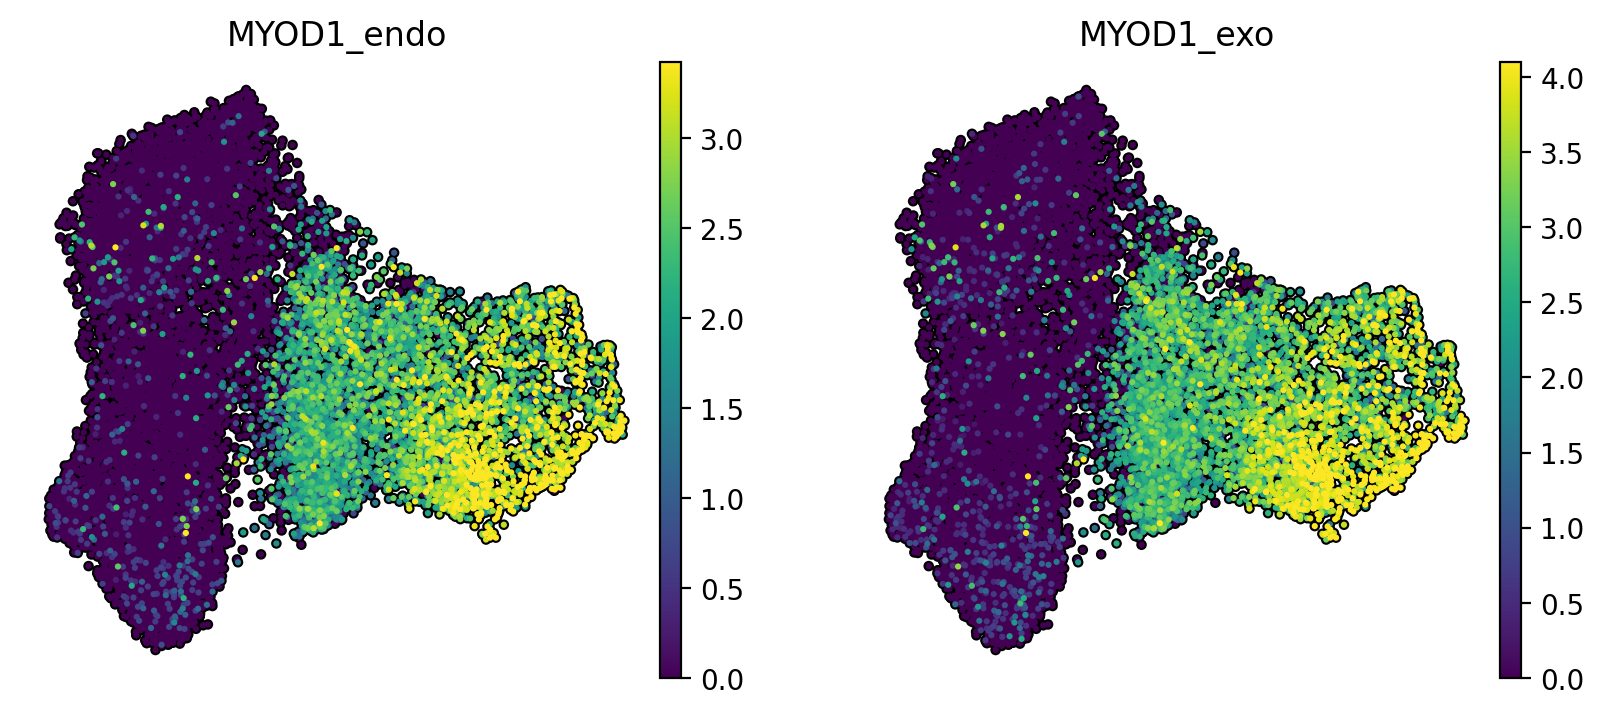

In [13]:
plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 4, 4

sc.pl.umap(
    adata_expanded,
    color=['MYOD1_endo', 'MYOD1_exo'],
    size=20,
    ncols=2,
    add_outline=True,
    outline_color=('k', 'k'),
    frameon=False,
    alpha=1,
    layer='log_norm',
    vmin='p2',
    vmax='p98',
)

In [14]:
# convert to sparse matrix
for layer in ['log_norm', 'raw_counts', 'raw_counts_new', 'norm']:
    if layer in adata_expanded.layers:
        if not sp.issparse(adata_expanded.layers[layer]):
            adata_expanded.layers[layer] = sp.csr_matrix(adata_expanded.layers[layer])

# Also convert X if it's dense
if not sp.issparse(adata_expanded.X):
    adata_expanded.X = sp.csr_matrix(adata_expanded.X)

    
adata_expanded

AnnData object with n_obs × n_vars = 16296 × 25128
    obs: 'MYOD-fb_counts', 'PRRX1-fb_counts', 'PRRX1_MYOD-fb_counts', 'assigned_condition', 'total_fb_counts', 'condition_counts_rate', 'G1-fb_counts', 'G2M-fb_counts', 'S-fb_counts', 'dataset', 'total_reads', 'total_genes', 'pooled_condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier', 'mt_outlier', 'n_genes', 'doublet_score', 'predicted_doublet', 'S_score', 'G2M_score', 'phase', 'leiden', 'cluster_str', 'leiden_split'
    var: 'gene_id', 'gene_type', 'Chromosome', 'Start', 'End', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'mean', 'st

# Write out

In [15]:
# outpath = "/scratch/indikar_root/indikar1/shared_data/HYB/endo_vs_exo/processed_all_groups_wExoEndo.h5ad"
outpath = "/scratch/indikar_root/indikar1/shared_data/HYB/endo_vs_exo/processed_all_groups_wExoEndo_v2.h5ad"

adata_expanded.write(outpath)
adata_expanded

AnnData object with n_obs × n_vars = 16296 × 25128
    obs: 'MYOD-fb_counts', 'PRRX1-fb_counts', 'PRRX1_MYOD-fb_counts', 'assigned_condition', 'total_fb_counts', 'condition_counts_rate', 'G1-fb_counts', 'G2M-fb_counts', 'S-fb_counts', 'dataset', 'total_reads', 'total_genes', 'pooled_condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier', 'mt_outlier', 'n_genes', 'doublet_score', 'predicted_doublet', 'S_score', 'G2M_score', 'phase', 'leiden', 'cluster_str', 'leiden_split'
    var: 'gene_id', 'gene_type', 'Chromosome', 'Start', 'End', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'mean', 'st